# Task 10 - Data Preprocessing

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import warnings
warnings.filterwarnings("ignore")

## Read Data

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1- Data Understanding

In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
# target column is charges
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

There are no ID or name columns in this dataset, so I will keep all columns.

## 2- Check Datatypes

In [7]:
dtypes = df.dtypes
n_unique = df.nunique()

pd.DataFrame({
    "Dtype": dtypes,
    "Num_Unique": n_unique
}).T

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,object,float64,int64,object,object,float64
Num_Unique,47,2,548,6,2,4,1337


In [8]:
cat_cols = ['sex', 'smoker', 'region']
df[cat_cols] = df[cat_cols].astype('category')

df.dtypes

age            int64
sex         category
bmi          float64
children       int64
smoker      category
region      category
charges      float64
dtype: object

## 3- Handle Null Values

In [9]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100

pd.DataFrame({
    "Null": null,
    "Ratio %": ratio
}).T

,age,sex,bmi,children,smoker,region,charges
Null,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio %,0.0,0.0,0.0,0.0,0.0,0.0,0.0


There are no null values in this dataset.

## 4- Handle Outliers

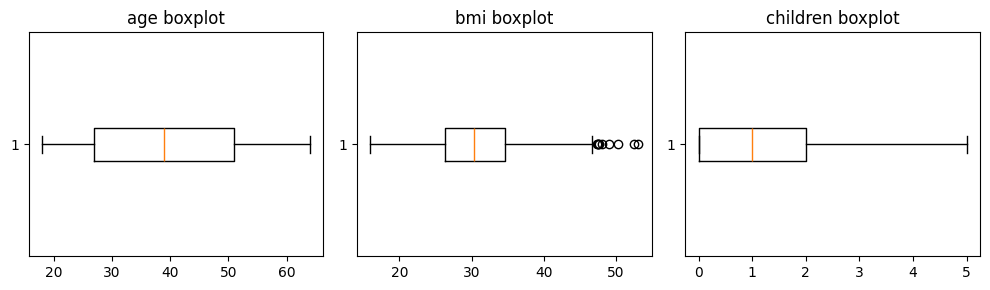

In [10]:
num_cols = ['age', 'bmi', 'children']

plt.figure(figsize=(10,3))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    plt.boxplot(df[col], vert=False)
    plt.title(f"{col} boxplot")
plt.tight_layout()
plt.show()

In [11]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    Lower_Fence = Q1 - 1.5 * IQR
    Upper_Fence = Q3 + 1.5 * IQR

    df.loc[df[col] < Lower_Fence, col] = Lower_Fence
    df.loc[df[col] > Upper_Fence, col] = Upper_Fence

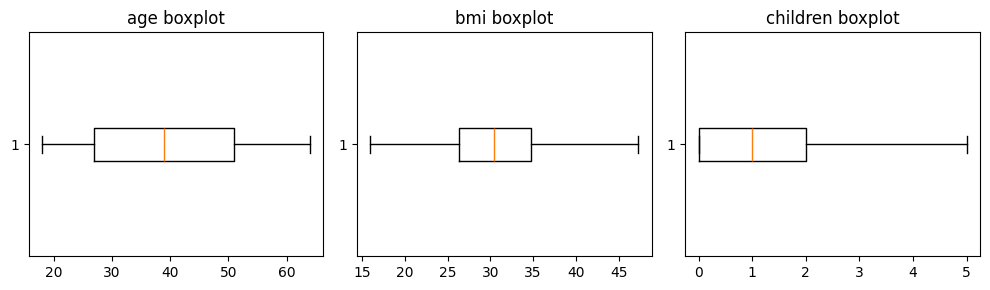

In [12]:
plt.figure(figsize=(10,3))
for i, col in enumerate(num_cols):
    plt.subplot(1,3,i+1)
    plt.boxplot(df[col], vert=False)
    plt.title(f"{col} boxplot")
plt.tight_layout()
plt.show()

## 5- Remove Duplicates

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

## 6- Visualization

### Histogram

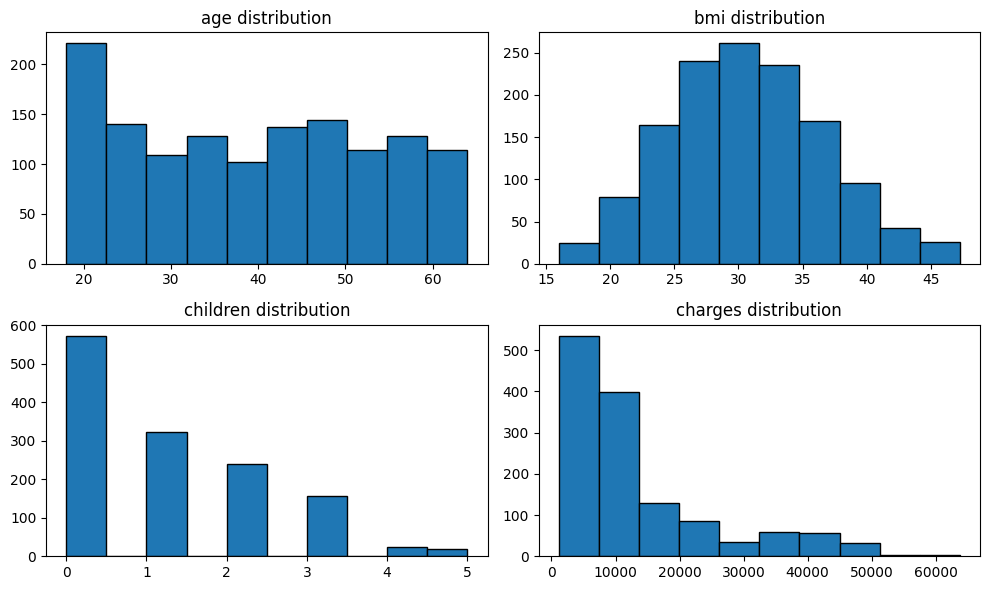

In [15]:
num_cols_all = df.select_dtypes('number').columns

plt.figure(figsize=(10,6))
for i, col in enumerate(num_cols_all):
    plt.subplot(2,2,i+1)
    plt.hist(df[col], edgecolor='black')
    plt.title(f"{col} distribution")
plt.tight_layout()
plt.show()

### KDE Plot

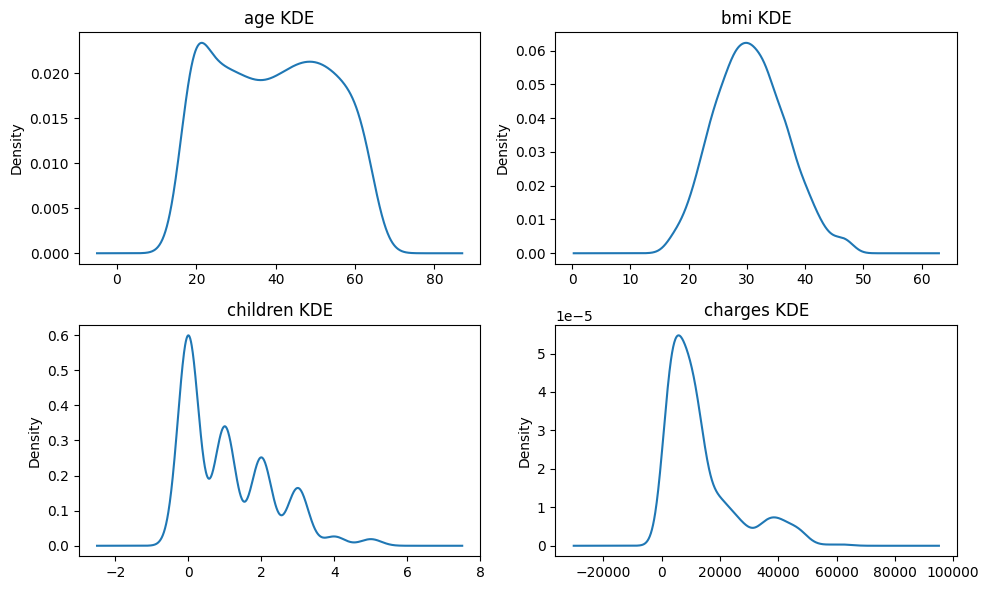

In [16]:
plt.figure(figsize=(10,6))
for i, col in enumerate(num_cols_all):
    plt.subplot(2,2,i+1)
    df[col].plot(kind='kde')
    plt.title(f"{col} KDE")
plt.tight_layout()
plt.show()

### Count Plot

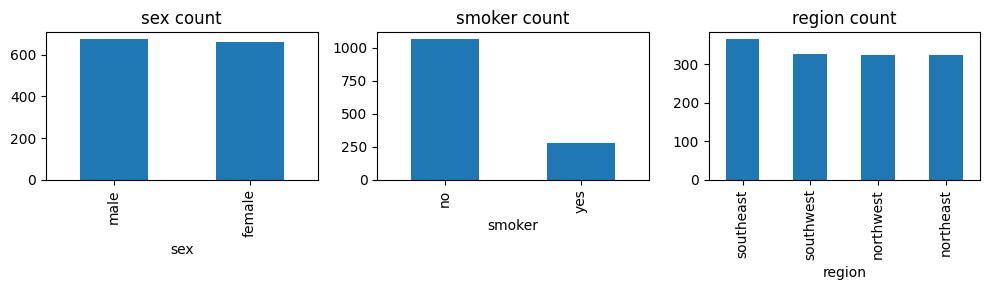

In [17]:
cat_cols = df.select_dtypes('category').columns

plt.figure(figsize=(10,3))
for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    df[col].value_counts().plot(kind='bar')
    plt.title(f"{col} count")
plt.tight_layout()
plt.show()

### Pie Plot

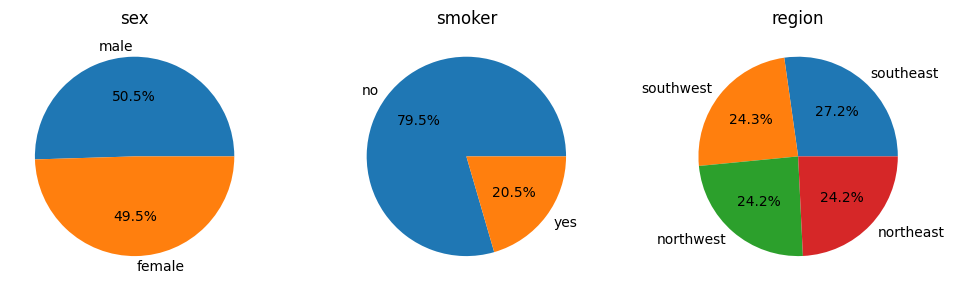

In [18]:
plt.figure(figsize=(10,3))
for i, col in enumerate(cat_cols):
    plt.subplot(1,3,i+1)
    values = df[col].value_counts()
    plt.pie(values.values, labels=values.index, autopct='%1.1f%%')
    plt.title(col)
plt.tight_layout()
plt.show()

### Box Plot

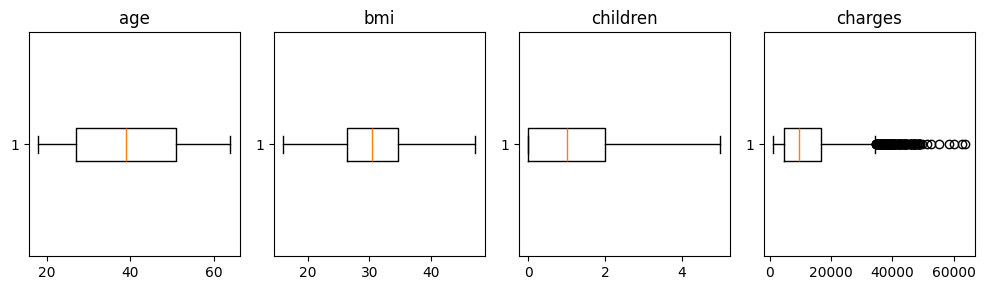

In [19]:
plt.figure(figsize=(10,3))
for i, col in enumerate(num_cols_all):
    plt.subplot(1,4,i+1)
    plt.boxplot(df[col], vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()

### Scatter Plot

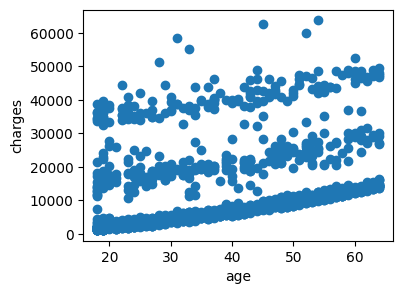

In [20]:
plt.figure(figsize=(4,3))
plt.scatter(df['age'], df['charges'])
plt.xlabel('age')
plt.ylabel('charges')
plt.show()

### Pair Plot

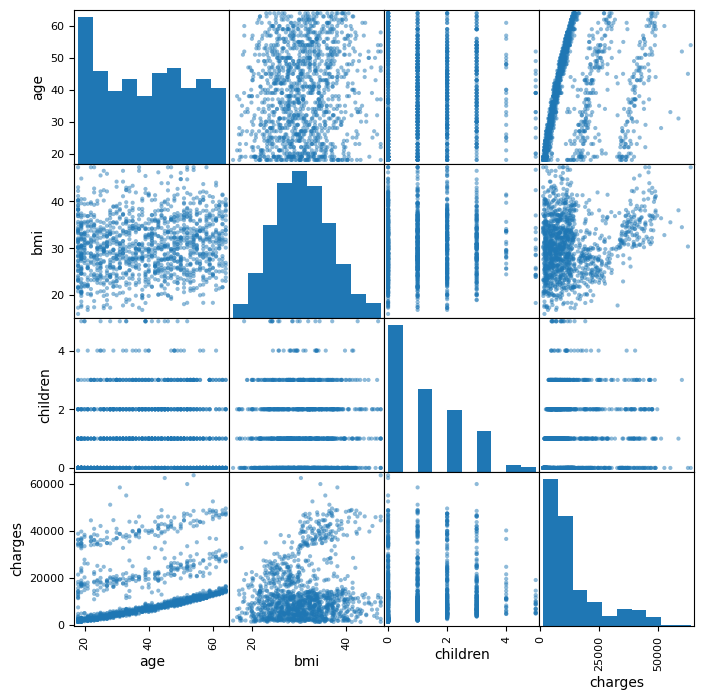

In [21]:
scatter_matrix(
    df[['age', 'bmi', 'children', 'charges']],
    figsize=(8,8),
    diagonal='hist'
)
plt.show()

### Correlation Heatmap

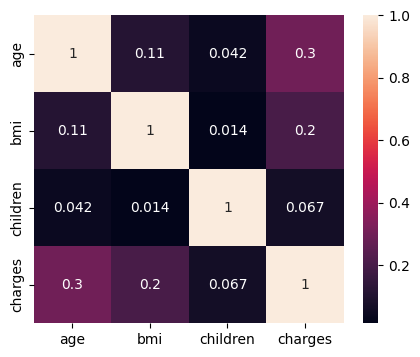

In [22]:
corr = df.select_dtypes('number').corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr, annot=True)
plt.show()

### Numerical / Categorical

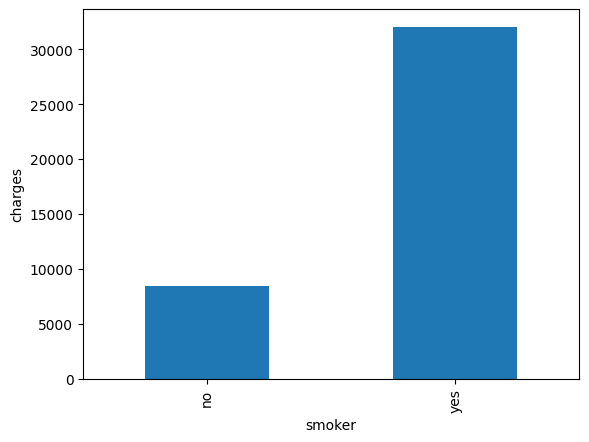

In [23]:
df.groupby('smoker', observed=False)['charges'].mean().plot(kind='bar')
plt.ylabel('charges')
plt.show()

### Categorical / Categorical

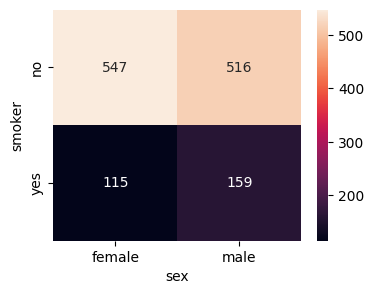

In [24]:
agg = pd.crosstab(df['smoker'], df['sex'])

plt.figure(figsize=(4,3))
sns.heatmap(agg, annot=True, fmt='d')
plt.show()

## 7- Data Splitting

In [25]:
X = df.drop('charges', axis=1)
y = df['charges']

In [26]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,female,27.900,0,yes,southwest
1,18,male,33.770,1,no,southeast
2,28,male,33.000,3,no,southeast
3,33,male,22.705,0,no,northwest
4,32,male,28.880,0,no,northwest


In [27]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## 8- Normalization

In [28]:
from sklearn.preprocessing import MinMaxScaler

num_cols = X.select_dtypes('number').columns
scaler = MinMaxScaler()

scaler.fit(X[num_cols])
X[num_cols] = scaler.transform(X[num_cols])

X.head()

,age,sex,bmi,children,smoker,region
0,0.021739,female,0.381104,0.0,yes,southwest
1,0.000000,male,0.568465,0.2,no,southeast
2,0.217391,male,0.543888,0.6,no,southeast
3,0.326087,male,0.215289,0.0,no,northwest
4,0.304348,male,0.412384,0.0,no,northwest


## 9- Encoding

In [29]:
str_cols = X.select_dtypes('category').columns

X = pd.get_dummies(X, columns=str_cols, dtype=int)

X.head()

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.381104,0.0,1,0,0,1,0,0,0,1
1,0.000000,0.568465,0.2,0,1,1,0,0,0,1,0
2,0.217391,0.543888,0.6,0,1,1,0,0,0,1,0
3,0.326087,0.215289,0.0,0,1,1,0,0,1,0,0
4,0.304348,0.412384,0.0,0,1,1,0,0,1,0,0


## Final Check

In [30]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Null values:", X.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

X.head()

X shape: (1337, 11)
y shape: (1337,)
Null values: 0
Duplicates: 0


,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,0.021739,0.381104,0.0,1,0,0,1,0,0,0,1
1,0.000000,0.568465,0.2,0,1,1,0,0,0,1,0
2,0.217391,0.543888,0.6,0,1,1,0,0,0,1,0
3,0.326087,0.215289,0.0,0,1,1,0,0,1,0,0
4,0.304348,0.412384,0.0,0,1,1,0,0,1,0,0
